In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import load_wine
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

### Regresja i regularyzacja (zbiór WINE)

In [2]:
data = load_wine()
X = data.data
X = pd.DataFrame(X, columns=data.feature_names)

In [3]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
X.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

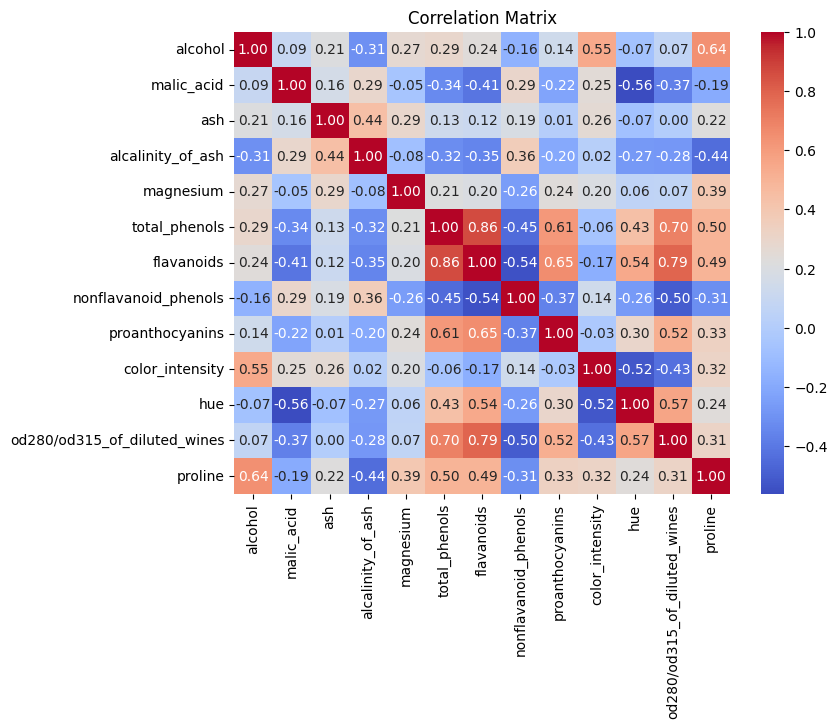

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

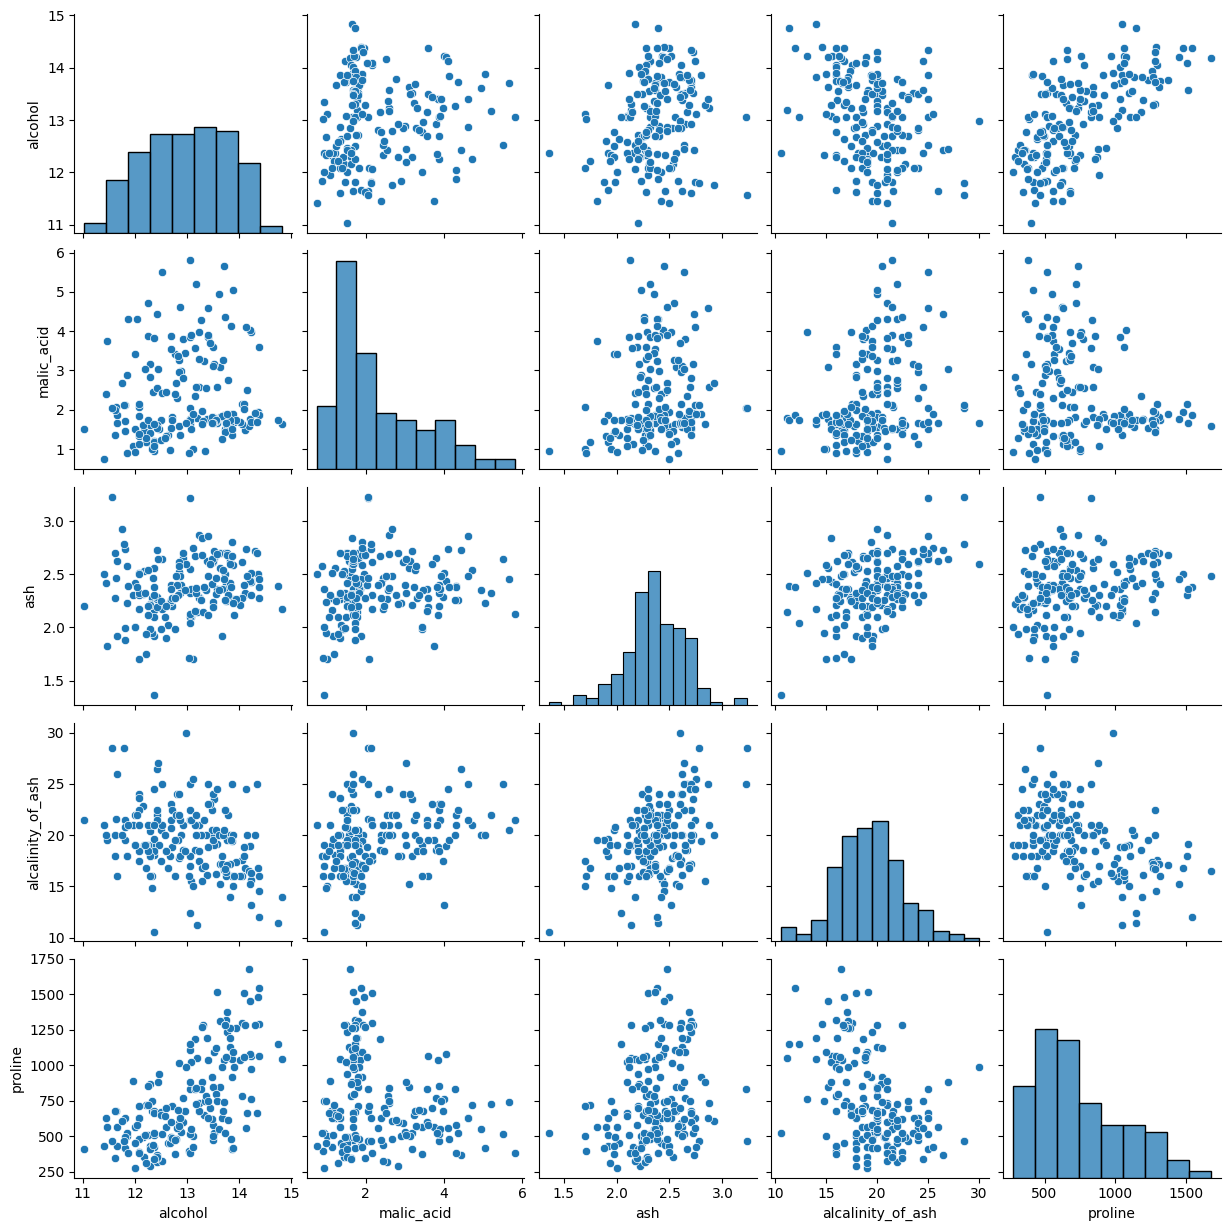

In [6]:
sns.pairplot(X[["alcohol", "malic_acid", "ash", "alcalinity_of_ash", "proline"]])

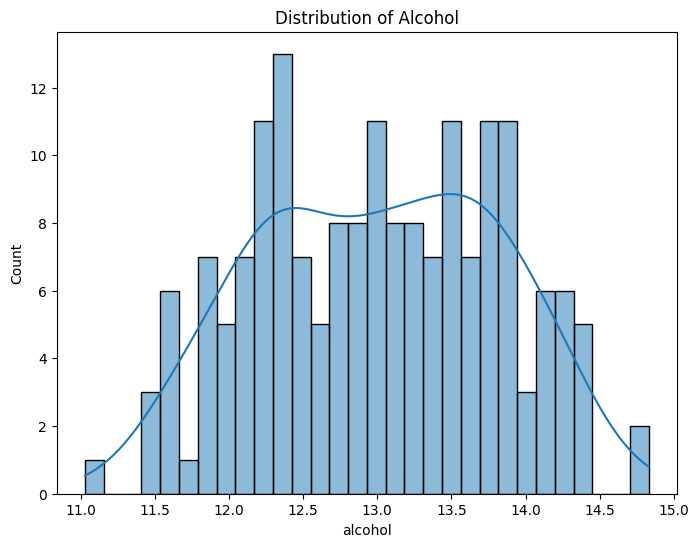

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(X["alcohol"], bins=30, kde=True)

plt.title("Distribution of Alcohol")
plt.show()

In [8]:
y = X["alcohol"]
X = X.drop(columns=["alcohol"])

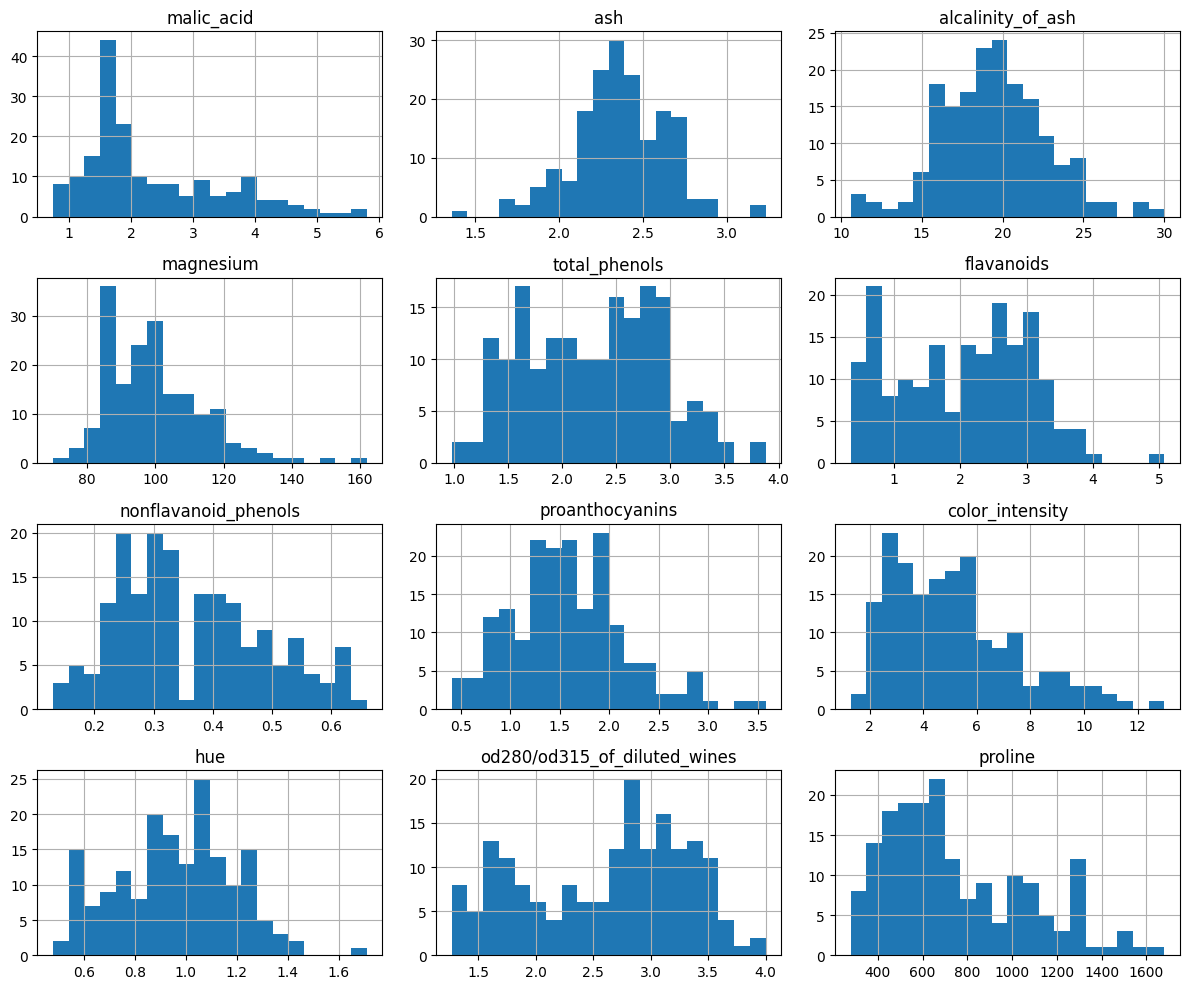

In [9]:
X.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

___

In [ ]:
regression_pipeline = Pipeline(
    [(
        "scaler", StandardScaler()), 
        ("regressor", LinearRegression())
    ]    
)

regression_pipeline.fit(X_train, y_train)
y_pred = regression_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

y_pred_train = regression_pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"Train MSE: {train_mse:.2f}, Train R²: {train_r2:.2f}")
print(f"Test MSE: {test_mse:.2f}, Test R²: {test_r2:.2f}")

Train MSE: 0.24, Train R²: 0.62
Test MSE: 0.41, Test R²: 0.40


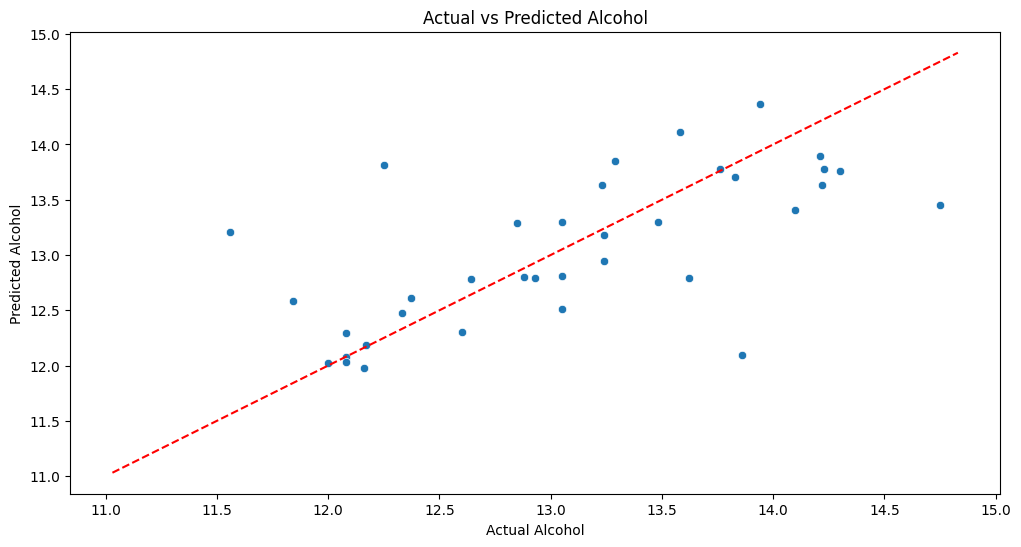

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Alcohol")
plt.ylabel("Predicted Alcohol")
plt.title("Actual vs Predicted Alcohol")
plt.show()

### Analiza reszt (Residual Plot)

Jeśli model jest dobrze dopasowany, reszty powinny być losowe — bez struktury, symetrycznie rozłożone wokół zera. Widoczny wzorzec (np. paraboliczny) sugeruje, że zależność jest nieliniowa i model liniowy czegoś nie wychwytuje.

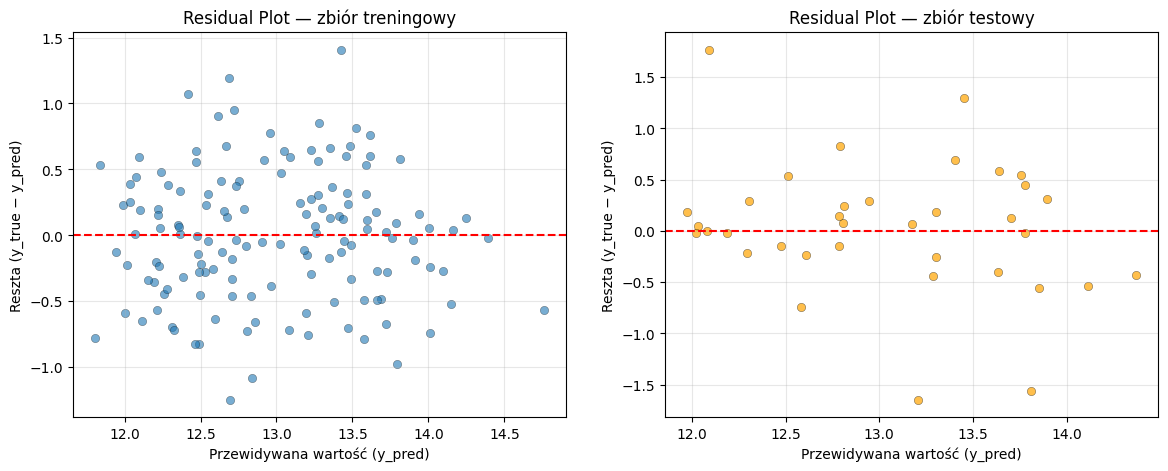

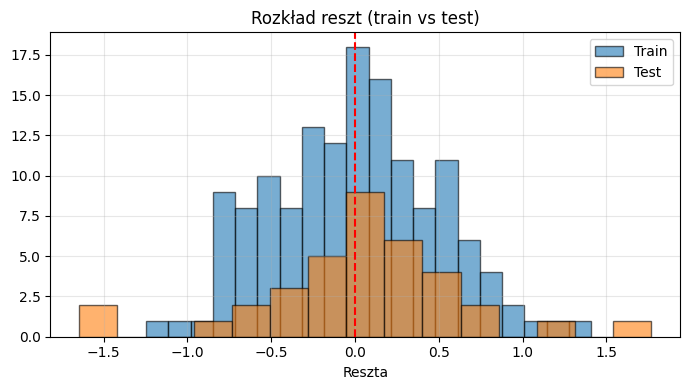

In [14]:
residuals_train = y_train - regression_pipeline.predict(X_train)
residuals_test = y_test - regression_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    regression_pipeline.predict(X_train),
    residuals_train,
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3,
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Przewidywana wartość (y_pred)")
axes[0].set_ylabel("Reszta (y_true − y_pred)")
axes[0].set_title("Residual Plot — zbiór treningowy")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    regression_pipeline.predict(X_test),
    residuals_test,
    alpha=0.7,
    color="orange",
    edgecolors="k",
    linewidths=0.3,
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Przewidywana wartość (y_pred)")
axes[1].set_ylabel("Reszta (y_true − y_pred)")
axes[1].set_title("Residual Plot — zbiór testowy")
axes[1].grid(True, alpha=0.3)

# histogram reszt
fig2, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals_train, bins=20, alpha=0.6, label="Train", edgecolor="k")
ax.hist(residuals_test, bins=15, alpha=0.6, label="Test", edgecolor="k")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Reszta")
ax.set_title("Rozkład reszt (train vs test)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

___

In [15]:
ridge_pipeline_generator = lambda alpha: Pipeline(
    [("scaler", StandardScaler()), ("regressor", Ridge(alpha=alpha))]
)

lasso_pipeline_generator = lambda alpha: Pipeline(
    [("scaler", StandardScaler()), ("regressor", Lasso(alpha=alpha))]
)

In [16]:
regression_alphas = np.logspace(-3, 5, 100)

ridge_coefs = []
lasso_coefs = []

for alpha in regression_alphas:
    ridge_model = ridge_pipeline_generator(alpha)
    ridge_model.fit(X_train, y_train)
    ridge_coefs.append(ridge_model.named_steps["regressor"].coef_)

    lasso_model = lasso_pipeline_generator(alpha)
    lasso_model.fit(X_train, y_train)
    lasso_coefs.append(lasso_model.named_steps["regressor"].coef_)

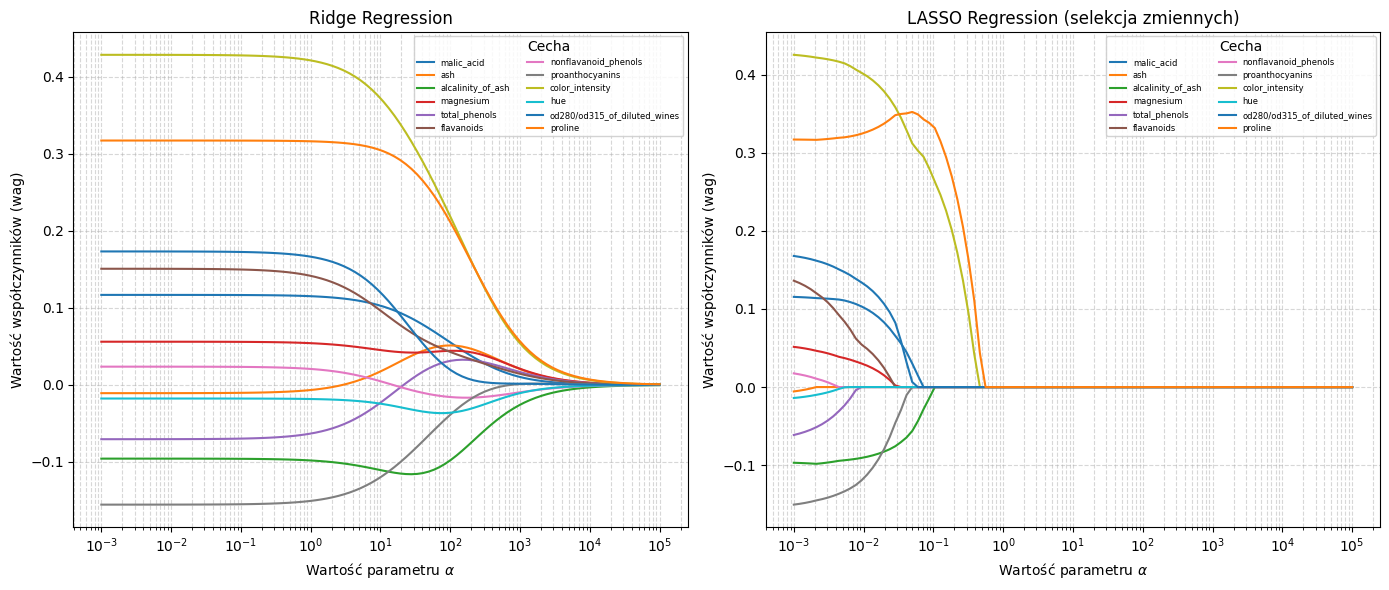

In [17]:
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

wine_feature_names = [feature for feature in data.feature_names if feature != "alcohol"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for feature_index, feature_name in enumerate(wine_feature_names):
    axes[0].plot(regression_alphas, ridge_coefs[:, feature_index], label=feature_name)
axes[0].set_xscale("log")
axes[0].set_xlabel("Wartość parametru $\\alpha$")
axes[0].set_ylabel("Wartość współczynników (wag)")
axes[0].set_title("Ridge Regression")
axes[0].grid(True, which="both", ls="--", alpha=0.5)
axes[0].legend(title="Cecha", loc="upper right", fontsize=6, ncol=2, framealpha=0.85)

for feature_index, feature_name in enumerate(wine_feature_names):
    axes[1].plot(regression_alphas, lasso_coefs[:, feature_index], label=feature_name)
axes[1].set_xscale("log")
axes[1].set_xlabel("Wartość parametru $\\alpha$")
axes[1].set_ylabel("Wartość współczynników (wag)")
axes[1].set_title("LASSO Regression (selekcja zmiennych)")
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend(title="Cecha", loc="upper right", fontsize=6, ncol=2, framealpha=0.85)

plt.tight_layout()
plt.show()

In [19]:
ridge = ridge_pipeline_generator(alpha=10)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print(
    f"Ridge Test MSE: {mean_squared_error(y_test, y_pred_ridge):.2f}, Ridge Test R2: {r2_score(y_test, y_pred_ridge):.2f}"
)

lasso = lasso_pipeline_generator(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(
    f"LASSO Test MSE: {mean_squared_error(y_test, y_pred_lasso):.2f}, LASSO Test R2: {r2_score(y_test, y_pred_lasso):.2f}"
)

Ridge Test MSE: 0.37, Ridge Test R2: 0.45
LASSO Test MSE: 0.37, LASSO Test R2: 0.46


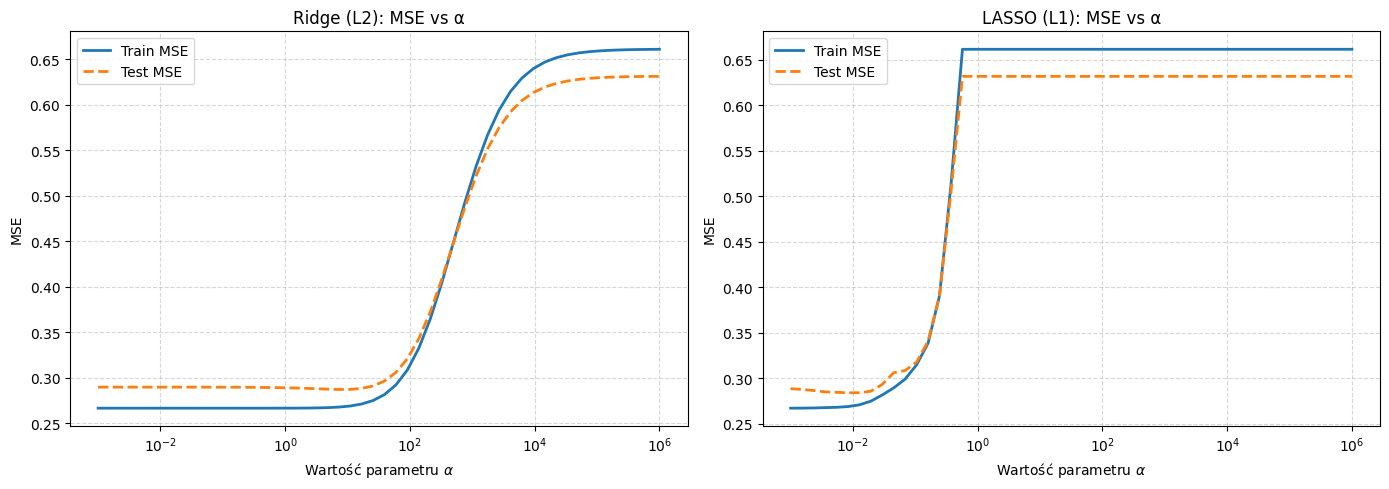

In [17]:
alphas = np.logspace(-3, 6, 50)

ridge_mse_train, ridge_mse_test = [], []
lasso_mse_train, lasso_mse_test = [], []

for alpha in alphas:
    model_r = ridge_pipeline_generator(alpha).fit(X_train, y_train)
    ridge_mse_train.append(mean_squared_error(y_train, model_r.predict(X_train)))
    ridge_mse_test.append(mean_squared_error(y_test, model_r.predict(X_test)))

    model_l = lasso_pipeline_generator(alpha).fit(X_train, y_train)
    lasso_mse_train.append(mean_squared_error(y_train, model_l.predict(X_train)))
    lasso_mse_test.append(mean_squared_error(y_test, model_l.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas, ridge_mse_train, label="Train MSE", linewidth=2)
axes[0].plot(alphas, ridge_mse_test, label="Test MSE", linewidth=2, linestyle="--")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"Wartość parametru $\alpha$")
axes[0].set_ylabel("MSE")
axes[0].set_title("Ridge (L2): MSE vs α")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(alphas, lasso_mse_train, label="Train MSE", linewidth=2)
axes[1].plot(alphas, lasso_mse_test, label="Test MSE", linewidth=2, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"Wartość parametru $\alpha$")
axes[1].set_ylabel("MSE")
axes[1].set_title("LASSO (L1): MSE vs α")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
alphas = np.logspace(-3, 5, 100)

ridge_grid_search = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "regressor",
            GridSearchCV(
                Ridge(),
                param_grid={"alpha": alphas},
                cv=5,
                scoring="neg_mean_squared_error",
            ),
        ),
    ]
)

lasso_grid_search = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "regressor",
            GridSearchCV(
                Lasso(),
                param_grid={"alpha": alphas},
                cv=5,
                scoring="neg_mean_squared_error",
            ),
        ),
    ]
)

ridge_grid_search.fit(X_train, y_train)
lasso_grid_search.fit(X_train, y_train)

mse_ridge = mean_squared_error(y_test, ridge_grid_search.predict(X_test))
mse_lasso = mean_squared_error(y_test, lasso_grid_search.predict(X_test))

r2_ridge = r2_score(y_test, ridge_grid_search.predict(X_test))
r2_lasso = r2_score(y_test, lasso_grid_search.predict(X_test))

best_ridge_alpha = ridge_grid_search.named_steps["regressor"].best_params_["alpha"]
best_lasso_alpha = lasso_grid_search.named_steps["regressor"].best_params_["alpha"]

print(
    f"Best Ridge alpha: {best_ridge_alpha:.4f} with MSE: {mse_ridge:.2f} and R²: {r2_ridge:.2f}"
)
print(
    f"Best Lasso alpha: {best_lasso_alpha:.4f} with MSE: {mse_lasso:.2f} and R²: {r2_lasso:.2f}"
)

Best Ridge alpha: 19.1791 with MSE: 0.29 and R²: 0.54
Best Lasso alpha: 0.0413 with MSE: 0.30 and R²: 0.52


Pojedynczy podział train/test jest podatny na losowość: wynik mocno zależy od tego, które konkretne próbki trafiły do zbioru testowego. Mały zbiór danych (jak WINE, 178 próbek) sprawia, że ta wariancja jest jeszcze większa — jeden "łatwy" lub "trudny" podział może zawyżyć lub zaniżyć MSE o kilkanaście procent.

**k-fold cross-validation** rozwiązuje ten problem:
- Dane są dzielone na *k* równych części (foldów). Model jest trenowany *k* razy, za każdym razem na *k−1* foldach, a testowany na pozostałym.
- Wynik końcowy to średnia z *k* pomiarów — jest stabilniejszy i bardziej reprezentatywny niż jeden pomiar.
- Każda próbka pojawia się dokładnie raz w zbiorze testowym, co eliminuje bias wynikający z konkretnego podziału.

___

In [20]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

In [21]:
mask = X["year"] == 4
X = X[mask].drop(columns=["year", "A37"])
y = y[mask].iloc[:, 0]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [23]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [25]:
pipeline = Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        ("regressor", LogisticRegression(class_weight="balanced", max_iter=5000)),
    ]
)

In [26]:
def evaluate_classification(y_true, y_pred):

    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred))

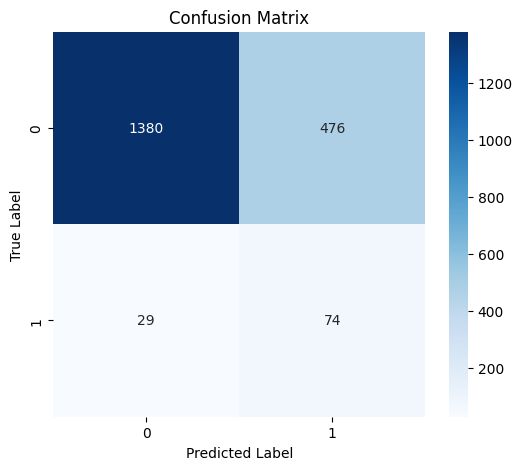

              precision    recall  f1-score   support

           0       0.98      0.74      0.85      1856
           1       0.13      0.72      0.23       103

    accuracy                           0.74      1959
   macro avg       0.56      0.73      0.54      1959
weighted avg       0.93      0.74      0.81      1959



In [27]:
model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_classification(y_test, y_pred)

### Interpretacja metryk klasyfikacji

Zbiór Bankruptcy jest silnie niezbalansowany: firmy bankrutujące to mniejszość (kilka % próbek). Dlatego **accuracy (dokładność)** jest myląca — model, który zawsze przewiduje "nie bankrutuje", ma bardzo wysoką dokładność, ale jest bezużyteczny.

**Macierz pomyłek** rozkłada wyniki na 4 przypadki:
- **True Positive (TP)**: firma faktycznie zbankrutowała i model to przewidział → dobrze
- **True Negative (TN)**: firma nie zbankrutowała i model to przewidział → dobrze
- **False Positive (FP)**: model przewidział bankructwo, ale firma przeżyła → fałszywy alarm
- **False Negative (FN)**: model nie przewidział bankructwa, a firma zbankrutowała → przeoczenie (najkosztowniejszy błąd!)

**Precyzja (Precision)** = TP / (TP + FP): spośród firm, które model oznaczył jako "bankrut", ile faktycznie zbankrutowało? Niska precyzja = dużo fałszywych alarmów.

**Czułość (Recall)** = TP / (TP + FN): spośród firm, które faktycznie zbankrutowały, ile model wykrył? Niska czułość = model przeoczywa bankructwa. W kontekście ryzyka finansowego **recall jest ważniejszy** — koszt przeoczenia bankructwa (strata kredytu) jest zwykle wyższy niż koszt fałszywego alarmu.

**F1-score** = harmoniczna średnia precision i recall — dobry summary metric gdy klasy są niezbalansowane.

Używamy `class_weight='balanced'`, żeby model nie ignorował mniejszościowej klasy bankrutów.


In [28]:
ridge_pipeline_generator = lambda alpha: Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(C=1 / alpha, l1_ratio=0.0, solver="saga", max_iter=5000),
        ),
    ]
)

lasso_pipeline_generator = lambda alpha: Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(C=1 / alpha, l1_ratio=1.0, solver="saga", max_iter=5000),
        ),
    ]
)

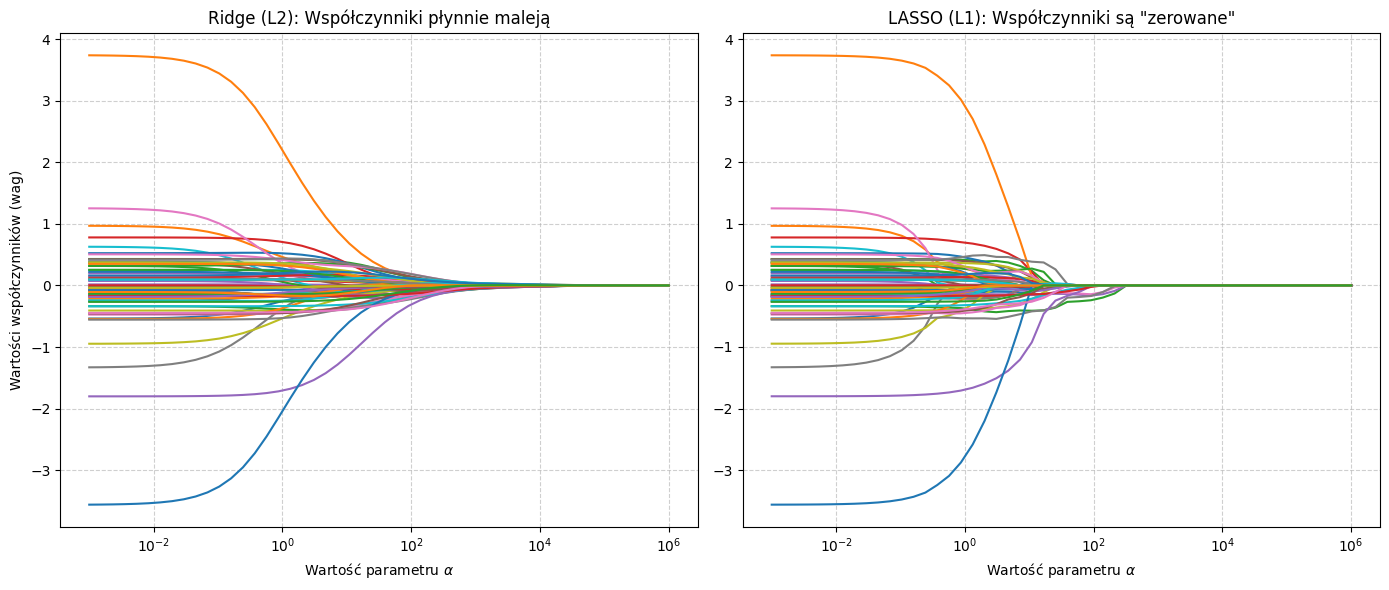

In [29]:
alphas = np.logspace(-3, 6, 50)

ridge_coefs = []
lasso_coefs = []
feature_names = X.columns

for alpha in alphas:
    model_r = ridge_pipeline_generator(alpha).fit(X_train, y_train)
    ridge_coefs.append(model_r.named_steps["classifier"].coef_[0])

    model_l = lasso_pipeline_generator(alpha).fit(X_train, y_train)
    lasso_coefs.append(model_l.named_steps["classifier"].coef_[0])

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot(alphas, ridge_coefs, label=feature_names)
axes[0].set_xscale("log")
axes[0].set_xlabel("Wartość parametru $\\alpha$")
axes[0].set_ylabel("Wartości współczynników (wag)")
axes[0].set_title("Ridge (L2): Współczynniki płynnie maleją")
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale("log")
axes[1].set_xlabel("Wartość parametru $\\alpha$")
axes[1].set_title('LASSO (L1): Współczynniki są "zerowane"')
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Regularization path — top 10 najważniejszych cech

Pełny wykres z 64 cechami jest nieczytelny. Poniżej pokazane są tylko cechy, które osiągnęły największą bezwzględną wartość współczynnika przy słabej regularyzacji — czyli te, które model uznał za najistotniejsze.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

Fitting 5 folds for each of 26 candidates, totalling 130 fits
Best regularization: L2
Best alpha: 0.005623 (C=177.827941)
Best CV f1_macro: 0.5380


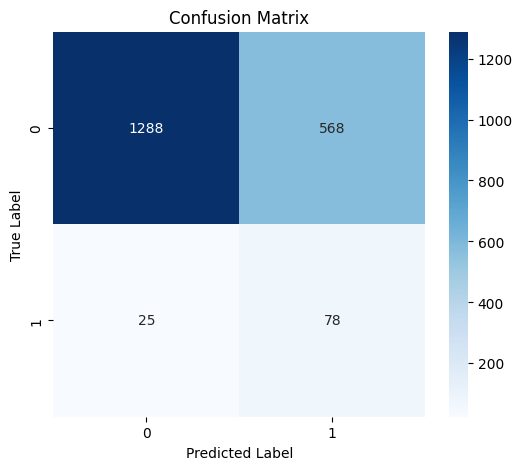

              precision    recall  f1-score   support

           0       0.98      0.69      0.81      1856
           1       0.12      0.76      0.21       103

    accuracy                           0.70      1959
   macro avg       0.55      0.73      0.51      1959
weighted avg       0.94      0.70      0.78      1959



In [55]:
alphas = np.logspace(-4, 3, 13)
c_values = 1 / alphas

logreg_pipeline = Pipeline(
    [
        ("median_imputer", SimpleImputer(strategy="median")),
        ("iqr_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                class_weight="balanced",
                max_iter=5000,
            ),
        ),
    ]
)

param_grid = {
    "classifier__l1_ratio": [0.0, 1.0],
    "classifier__C": c_values,
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

logreg_grid.fit(X_train, y_train)

best_c = logreg_grid.best_params_["classifier__C"]
best_alpha = 1 / best_c
best_l1_ratio = logreg_grid.best_params_["classifier__l1_ratio"]
best_reg = "L1" if best_l1_ratio == 1.0 else "L2"

print(f"Best regularization: {best_reg}")
print(f"Best alpha: {best_alpha:.6f} (C={best_c:.6f})")
print(f"Best CV f1_macro: {logreg_grid.best_score_:.4f}")

y_pred_grid = logreg_grid.predict(X_test)
evaluate_classification(y_test, y_pred_grid)

### Analiza progu klasyfikacji (ROC)

Krzywa ROC pokazuje kompromis między czułością i liczbą fałszywych alarmów. Dla najlepszego modelu wyznaczam AUC oraz próg maksymalizujący statystykę Youdena $J = TPR - FPR$, a następnie porównuję go z domyślnym progiem 0.5.

In [33]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

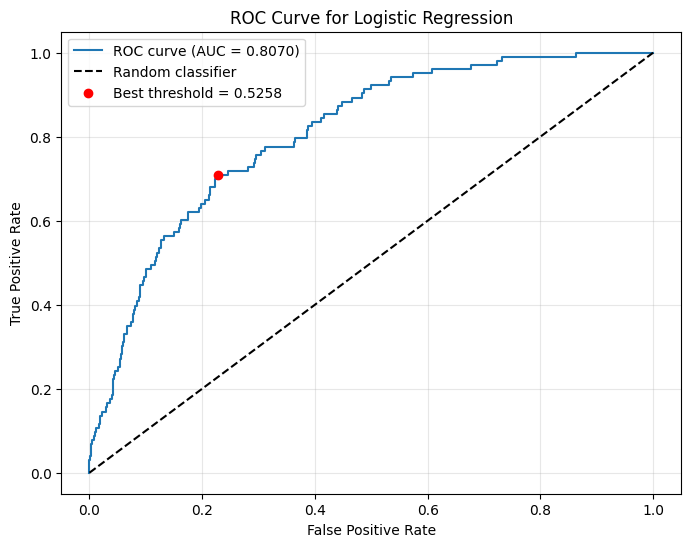

ROC AUC: 0.8070
Best threshold by Youden J: 0.5258


In [34]:
y_proba_grid = logreg_grid.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_grid)
roc_auc = roc_auc_score(y_test, y_proba_grid)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

default_pred = (y_proba_grid >= 0.5).astype(int)
best_threshold_pred = (y_proba_grid >= best_threshold).astype(int)

default_metrics = {
    "accuracy": accuracy_score(y_test, default_pred),
    "precision": precision_score(y_test, default_pred, zero_division=0),
    "recall": recall_score(y_test, default_pred, zero_division=0),
    "f1": f1_score(y_test, default_pred, zero_division=0),
}
best_metrics = {
    "accuracy": accuracy_score(y_test, best_threshold_pred),
    "precision": precision_score(y_test, best_threshold_pred, zero_division=0),
    "recall": recall_score(y_test, best_threshold_pred, zero_division=0),
    "f1": f1_score(y_test, best_threshold_pred, zero_division=0),
}

threshold_summary = pd.DataFrame(
    [
        {"threshold": 0.50, **default_metrics},
        {"threshold": best_threshold, **best_metrics},
    ]
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.scatter(
    fpr[best_idx],
    tpr[best_idx],
    color="red",
    zorder=5,
    label=f"Best threshold = {best_threshold:.4f}",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Best threshold by Youden J: {best_threshold:.4f}")

### Threshold sweep — kompromis precision/recall/F1

Wykres pokazuje jak precision, recall i F1-score zmieniają się w zależności od progu klasyfikacji. Pozwala świadomie wybrać próg dostosowany do potrzeb biznesowych: niższy próg → wyższy recall (mniej przeoczonych bankrutów), wyższy próg → wyższa precyzja (mniej fałszywych alarmów).

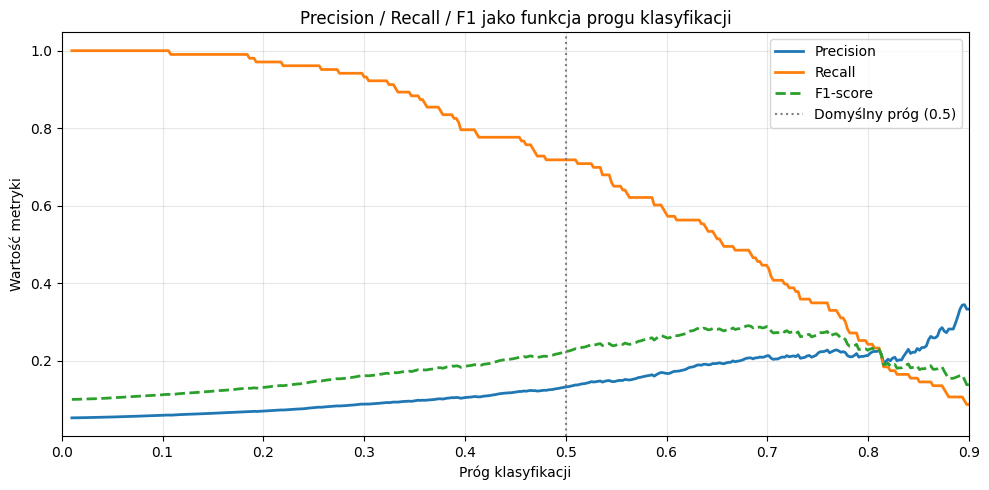

In [47]:
sweep_thresholds = np.linspace(0.01, 0.9, 400)
precisions, recalls, f1s = [], [], []

for t in sweep_thresholds:
    preds = (y_proba_grid >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(sweep_thresholds, precisions, label="Precision", linewidth=2)
plt.plot(sweep_thresholds, recalls, label="Recall", linewidth=2)
plt.plot(sweep_thresholds, f1s, label="F1-score", linewidth=2, linestyle="--")
plt.axvline(0.5, color="gray", linestyle=":", label="Domyślny próg (0.5)")
plt.xlabel("Próg klasyfikacji")
plt.ylabel("Wartość metryki")
plt.xlim(0, 0.9)
plt.title("Precision / Recall / F1 jako funkcja progu klasyfikacji")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
feature_names = X_train.columns.tolist()
grid_results = pd.DataFrame(logreg_grid.cv_results_)


def fit_regularized_logreg(l1_ratio, override_c=None):
    regularization_name = "L1" if l1_ratio == 1.0 else "L2"
    subset = grid_results[
        grid_results["param_classifier__l1_ratio"].astype(float) == l1_ratio
    ].copy()
    best_row = subset.loc[subset["mean_test_score"].idxmax()]
    best_c = float(
        override_c if override_c is not None else best_row["param_classifier__C"]
    )
    best_alpha = 1 / best_c

    model = Pipeline(
        [
            ("median_imputer", SimpleImputer(strategy="median")),
            ("iqr_clipper", IQRClipper(k=1.5)),
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    solver="saga",
                    class_weight="balanced",
                    max_iter=5000,
                    l1_ratio=l1_ratio,
                    C=best_c,
                ),
            ),
        ]
    )
    model.fit(X_train, y_train)

    coefficients = model.named_steps["classifier"].coef_[0]
    coef_table = pd.DataFrame(
        {
            "feature": feature_names,
            "coef": coefficients,
            "abs_coef": np.abs(coefficients),
        }
    ).sort_values("abs_coef", ascending=False)
    zero_count = int(np.sum(np.isclose(coefficients, 0.0, atol=1e-8)))
    near_zero_count = int(np.sum(np.abs(coefficients) < 1e-4))

    return {
        "regularization": regularization_name,
        "l1_ratio": l1_ratio,
        "C": best_c,
        "alpha": best_alpha,
        "zero_count": zero_count,
        "near_zero_count": near_zero_count,
        "coef_table": coef_table,
    }


l1_summary = fit_regularized_logreg(1.0)
l2_summary = fit_regularized_logreg(0.0)
l1_sparse_demo = fit_regularized_logreg(1.0, override_c=float(np.min(c_values)))

comparison = pd.DataFrame(
    [
        {
            "model": "L1",
            "C": l1_summary["C"],
            "alpha": l1_summary["alpha"],
            "zero_coefficients": l1_summary["zero_count"],
            "near_zero_coefficients": l1_summary["near_zero_count"],
        },
        {
            "model": "L2",
            "C": l2_summary["C"],
            "alpha": l2_summary["alpha"],
            "zero_coefficients": l2_summary["zero_count"],
            "near_zero_coefficients": l2_summary["near_zero_count"],
        },
    ]
)

print("Porównanie najlepszych modeli regularyzacji:")
display(comparison)

print("Najważniejsze cechy dla L1 (top 8):")
display(l1_summary["coef_table"].head(8))

print("Najważniejsze cechy dla L2 (top 8):")
display(l2_summary["coef_table"].head(8))

Porównanie najlepszych modeli regularyzacji:


,model,C,alpha,zero_coefficients,near_zero_coefficients
0,L1,2610.157216,0.000383,0,0
1,L2,0.056234,17.782794,0,0


Najważniejsze cechy dla L1 (top 8):


,feature,coef,abs_coef
16,A17,3.001005,3.001005
7,A8,-2.972693,2.972693
31,A32,1.881360,1.881360
50,A52,-1.702719,1.702719
44,A46,-1.368056,1.368056
1,A2,1.365598,1.365598
9,A10,1.125141,1.125141
10,A11,0.943974,0.943974


Najważniejsze cechy dla L2 (top 8):


,feature,coef,abs_coef
44,A46,-1.079172,1.079172
31,A32,0.726813,0.726813
47,A49,0.529564,0.529564
10,A11,0.526327,0.526327
3,A4,0.521299,0.521299
50,A52,-0.509433,0.509433
36,A38,-0.495103,0.495103
2,A3,0.444643,0.444643


| Cecha | Znaczenie / Wzór |
|-------|-----------------|
| A17 | marże (zysk / sprzedaż) |
| A8 | zysk / aktywa |
| A32 | (obecne zobowiązania × 365) / koszty produkcji |
| A52 | (krótkoterminowe zobowiązania × 365) / koszty produkcji |
| A46 | (aktywa obrotowe – zapasy) / zobowiązania krótkoterminowe (quick ratio) |
| A11 | (zysk + różne dodatki) / aktywa |
| A49 | EBITDA / sprzedaż (marża operacyjna) |
| A4 | aktywa obrotowe / zobowiązania krótkoterminowe (current ratio) |
| A38 | kapitał stały / aktywa |

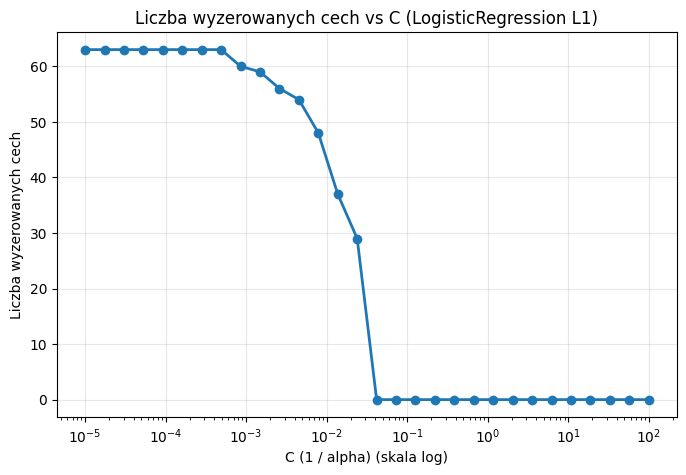

,C,zero_coefficients
0,0.000010,63
1,0.000017,63
2,0.000030,63
3,0.000053,63
4,0.000092,63
5,0.000161,63
6,0.000281,63
7,0.000489,63
8,0.000853,60
9,0.001487,59


In [49]:
c_values = np.logspace(-5, 2, 30)
c_values_sorted = np.sort(np.array(c_values, dtype=float))
zero_counts = []

for c in c_values_sorted:
    l1_for_c = fit_regularized_logreg(1.0, override_c=float(c))
    zero_counts.append(l1_for_c["zero_count"])

sparsity_vs_c = pd.DataFrame(
    {
        "C": c_values_sorted,
        "zero_coefficients": zero_counts,
    }
)

plt.figure(figsize=(8, 5))
plt.plot(
    sparsity_vs_c["C"],
    sparsity_vs_c["zero_coefficients"],
    marker="o",
    linewidth=2,
)
plt.xscale("log")
plt.xlabel("C (1 / alpha) (skala log)")
plt.ylabel("Liczba wyzerowanych cech")
plt.title("Liczba wyzerowanych cech vs C (LogisticRegression L1)")
plt.grid(True, alpha=0.3)
plt.show()

display(sparsity_vs_c)